# Model Performance Comparison

Compare all models across metrics, grouped by model family:
- **GPT** (blue): GPT-4.1, GPT-5.4
- **Gemini** (orange): Gemini-2.5-Flash, Gemini-3.1-pro-preview
- **Qwen** (green): Base, Fine-Tuned (200 samples), Fine-Tuned (500 samples)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv("model_performance_tracker.csv", index_col=0)
print(df)

                                         AUC-ROC     BCE  Precision  Recall  \
GPT-4.1                                   0.8105  0.5566       0.78    0.74   
GPT-5.4                                   0.7869  0.5703       0.75    0.71   
Gemini-2.5-Flash                          0.8089  0.5468       0.72    0.80   
Gemini-3.1-pro-preview                    0.8358  0.5322       0.82    0.69   
Qwen-3-4B Base Model                      0.4638  1.0008       0.46    0.42   
Fine-Tuned Qwen-3-4B (200 *3, r8 QLoRA)   0.8645  0.5489       0.80    0.79   
Fine-Tuned Qwen-3-4B (500*3, r16 QLoRA)   0.9129  0.5131       0.80    0.87   

                                           F1  
GPT-4.1                                  0.76  
GPT-5.4                                  0.73  
Gemini-2.5-Flash                         0.76  
Gemini-3.1-pro-preview                   0.75  
Qwen-3-4B Base Model                     0.44  
Fine-Tuned Qwen-3-4B (200 *3, r8 QLoRA)  0.80  
Fine-Tuned Qwen-3-4B (500*3, r1

In [2]:
# ---- Derived metrics ----
df["Gini"] = 2 * df["AUC-ROC"] - 1
df["BCE Improvement"] = np.log(2) - df["BCE"]

# ---- Short display names ----
short_names = {
    "GPT-4.1": "GPT-4.1",
    "GPT-5.4": "GPT-5.4",
    "Gemini-2.5-Flash": "Gemini-2.5\nFlash",
    "Gemini-3.1-pro-preview": "Gemini-3.1\nPro",
    "Qwen-3-4B Base Model": "Qwen-3-4B\nBase",
    "Fine-Tuned Qwen-3-4B (200 *3, r8 QLoRA)": "Qwen-3-4B\nFT 200",
    "Fine-Tuned Qwen-3-4B (500*3, r16 QLoRA)": "Qwen-3-4B\nFT 500",
}
df["short_name"] = df.index.map(short_names)

# ---- Group colors ----
GPT_COLOR = "#4A90D9"
GEMINI_COLOR = "#E8913A"
QWEN_COLOR = "#5BB55B"

colors = [
    GPT_COLOR, GPT_COLOR,          # GPT-4.1, GPT-5.4
    GEMINI_COLOR, GEMINI_COLOR,    # Gemini-2.5, Gemini-3.1
    QWEN_COLOR, QWEN_COLOR, QWEN_COLOR,  # Base, FT-200, FT-500
]

print(df[["Gini", "BCE Improvement", "Precision", "Recall", "F1"]])

                                           Gini  BCE Improvement  Precision  \
GPT-4.1                                  0.6210         0.136547       0.78   
GPT-5.4                                  0.5738         0.122847       0.75   
Gemini-2.5-Flash                         0.6178         0.146347       0.72   
Gemini-3.1-pro-preview                   0.6716         0.160947       0.82   
Qwen-3-4B Base Model                    -0.0724        -0.307653       0.46   
Fine-Tuned Qwen-3-4B (200 *3, r8 QLoRA)  0.7290         0.144247       0.80   
Fine-Tuned Qwen-3-4B (500*3, r16 QLoRA)  0.8258         0.180047       0.80   

                                         Recall    F1  
GPT-4.1                                    0.74  0.76  
GPT-5.4                                    0.71  0.73  
Gemini-2.5-Flash                           0.80  0.76  
Gemini-3.1-pro-preview                     0.69  0.75  
Qwen-3-4B Base Model                       0.42  0.44  
Fine-Tuned Qwen-3-4B (200 *3, r

In [9]:
def plot_metric(values, labels, colors, title, ylabel, legend_patches, fmt=".2f"):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(range(len(values)), values, color=colors, edgecolor="white", width=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Value labels on bars
    for bar, val in zip(bars, values):
        y = bar.get_height()
        va = "bottom" if y >= 0 else "top"
        offset = 0.01 if y >= 0 else -0.01
        ax.text(bar.get_x() + bar.get_width() / 2, y + offset,
                f"{val:{fmt}}", ha="center", va=va, fontsize=9, fontweight="bold")

    # Group separators
    for x in [1.5, 3.5]:
        ax.axvline(x, color="grey", linewidth=0.5, linestyle=":", alpha=0.5)

    ax.legend(handles=legend_patches, loc="upper left", bbox_to_anchor=(1.01, 1),
              fontsize=9, frameon=False)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


legend_patches = [
    mpatches.Patch(color=GPT_COLOR, label="GPT"),
    mpatches.Patch(color=GEMINI_COLOR, label="Gemini"),
    mpatches.Patch(color=QWEN_COLOR, label="Qwen"),
]

labels = df["short_name"].tolist()

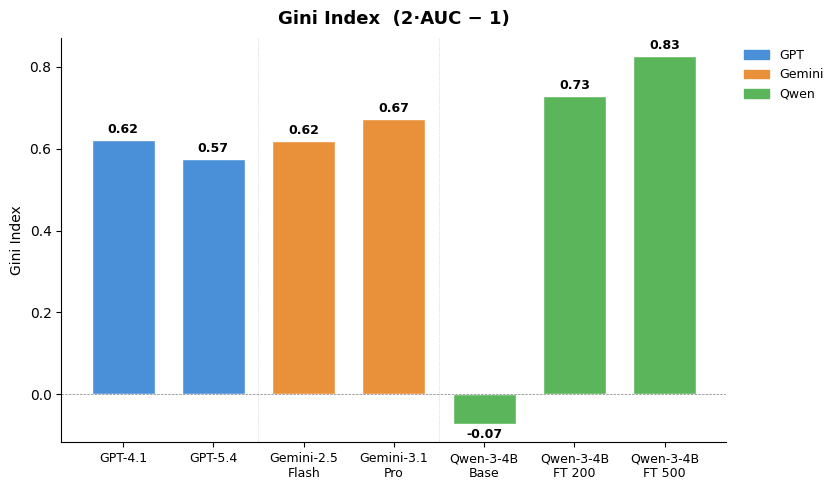

In [11]:
plot_metric(df["Gini"].values, labels, colors,
            "Gini Index  (2·AUC − 1)", "Gini Index", legend_patches)

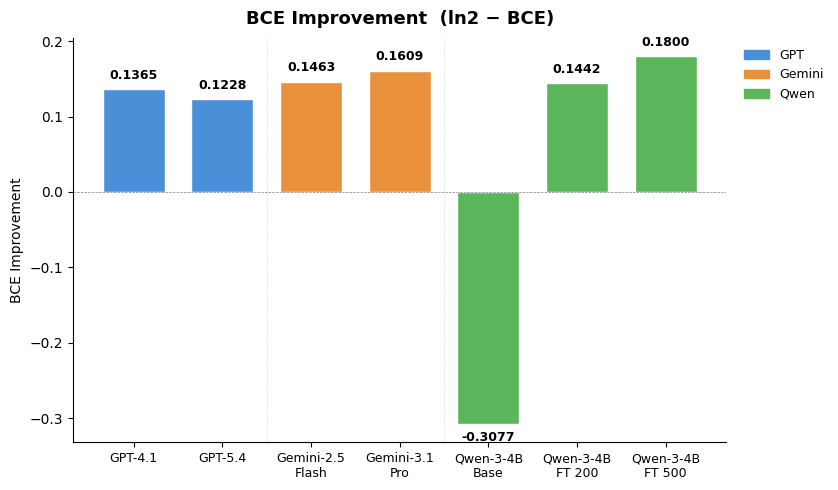

In [12]:
plot_metric(df["BCE Improvement"].values, labels, colors,
            "BCE Improvement  (ln2 − BCE)", "BCE Improvement", legend_patches, fmt=".4f")

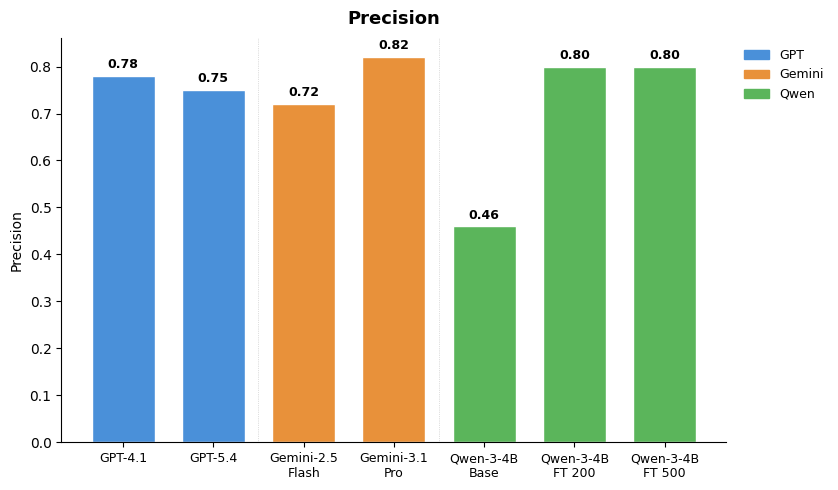

In [13]:
plot_metric(df["Precision"].values, labels, colors,
            "Precision", "Precision", legend_patches)

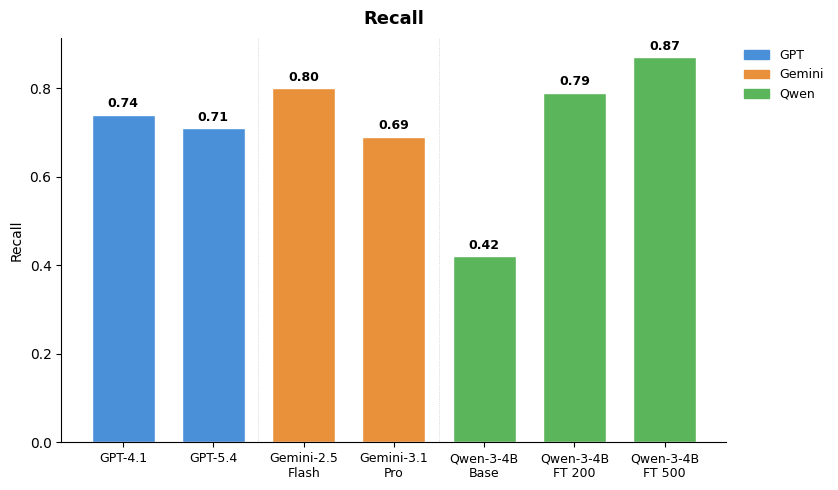

In [14]:
plot_metric(df["Recall"].values, labels, colors,
            "Recall", "Recall", legend_patches)

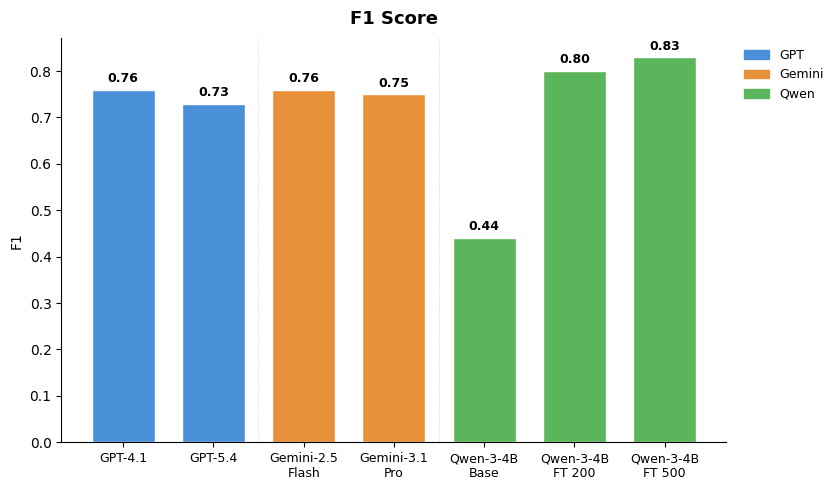

In [15]:
plot_metric(df["F1"].values, labels, colors,
            "F1 Score", "F1", legend_patches)